In [ ]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv.zip to spam.csv.zip


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import zipfile
import io

# Assuming 'uploaded' contains the zipped file content from the previous cell

# Find the zip file name from the uploaded dictionary keys
zip_file_name = None
for fn in uploaded.keys():
    if fn.endswith('.zip'):
        zip_file_name = fn
        break

if zip_file_name:
    # Unzip the file
    with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as z:
        z.extractall() # This will extract spam.csv (assuming it's directly inside the zip)
    print(f"Successfully unzipped {zip_file_name}")

    # Now, read the extracted csv file
    df = pd.read_csv("spam.csv", encoding='latin-1')
    print(df.head())
else:
    print("Error: No zip file found in the uploaded dictionary.")
    # If there's a specific non-zip file name that was intended, you might need to adjust here.

Successfully unzipped spam.csv.zip
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [ ]:
df = df[['v1', 'v2']]

df.columns = ['label', 'message']

print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

print(df.head())

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [ ]:
X = df['message']

y = df['label']

In [ ]:
cv = CountVectorizer()

X = cv.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test)

print(y_pred)

[1 0 1 ... 0 0 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.97847533632287


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[952  13]
 [ 11 139]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.91      0.93      0.92       150

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [ ]:
msg = ["Congratulations! You won a free lottery ticket"]

data = cv.transform(msg)

prediction = model.predict(data)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Not Spam")

Spam Message


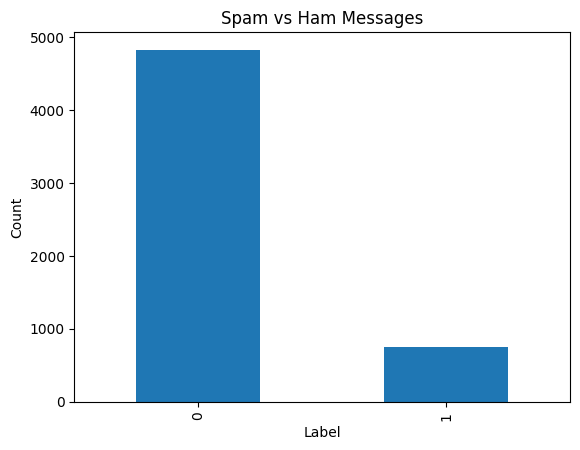

In [ ]:
df['label'].value_counts().plot(kind='bar')

plt.xlabel("Label")
plt.ylabel("Count")

plt.title("Spam vs Ham Messages")

plt.show()